In [1]:
import torch
import torch.distributions as dist
import neml2
from pyzag import stochastic, nonlinear, reparametrization, chunktime
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import copy
import numpy as np
import os
import re
import tqdm
import pandas as pd
from scipy.optimize import brentq
from neml2.cli.inspect import main as inspect_main
import math
import pyro
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.infer.autoguide import AutoDelta
from pyro.optim import ClippedAdam

/home/quantumsurfer/.local/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
torch.manual_seed(0)

torch.set_default_dtype(torch.double)
if torch.cuda.is_available():
    dev = "cuda:0"
    print("CUDA is available")
    print(f"CUDA version: {torch.version.cuda}")
else:
    dev = "cpu"
device = torch.device(dev)

CUDA is available
CUDA version: 13.0


In [3]:
class SolveStrain(torch.nn.Module):
    """Just integrate the model through some strain history

    Args:
        discrete_equations: the pyzag wrapped model
        nchunk (int): number of vectorized time steps
        rtol (float): relative tolerance to use for Newton's method during time integration
        atol (float): absolute tolerance to use for Newton's method during time integration
    """

    def __init__(
        self,
        discrete_equations,
        nchunk=1,
        rtol=1.0e-6,
        atol=1.0e-4,
        initial_rho_m=90.0,
        initial_tau_ss=100.0,
    ):
        super().__init__()
        self.discrete_equations = discrete_equations
        self.nchunk = nchunk
        self.cached_solution = None
        self.rtol = rtol
        self.atol = atol
        self.initial_rho_m = initial_rho_m
        self.initial_tau_ss = initial_tau_ss

    def forward(self, loading, time, temperature, cache=False):
        """Integrate through some time/temperature/strain history and return stress
        Args:
            time (torch.tensor): batched times
            temperature (torch.tensor): batched temperatures
            loading (torch.tensor): loading conditions, which are the input strain in the first base index and then the stress (zero) in the remainder

        Keyword Args:
            cache (bool): if true, cache the solution and use it as a predictor for the next call.
                This heuristic can speed things up during inference where the model is called repeatedly with similar parameter values.
        """
        if cache and self.cached_solution is not None:
            solver = nonlinear.RecursiveNonlinearEquationSolver(
                self.discrete_equations,
                step_generator=nonlinear.StepGenerator(self.nchunk),
                predictor=nonlinear.FullTrajectoryPredictor(self.cached_solution),  # type: ignore
                nonlinear_solver=chunktime.ChunkNewtonRaphson(
                    rtol=self.rtol, atol=self.atol, throw_on_fail=False
                ),
            )
        else:
            solver = nonlinear.RecursiveNonlinearEquationSolver(
                self.discrete_equations,
                step_generator=nonlinear.StepGenerator(self.nchunk),
                predictor=nonlinear.PreviousStepsPredictor(),  # type: ignore
                nonlinear_solver=chunktime.ChunkNewtonRaphson(
                    rtol=self.rtol, atol=self.atol, throw_on_fail=False
                ),
            )

        control = torch.zeros_like(loading)
        control[..., 1:] = 1.0

        # Pack the per-force raw tensors into the single flat forces tensor
        # pyzag consumes. ``assemble_forces`` uses the adapter's own force
        # layout, so the packing is guaranteed to match how the factory later
        # splits the tensor back apart (``_split_by_layout``); base sizes come
        # from the layout, so scalars need no trailing-1 unsqueeze here.
        forces = self.discrete_equations.assemble_forces(
            {
                "fixed_values": loading,
                "t": time,
                "temperature": temperature,
                "control": control,
            }
        )
        state0 = self.discrete_equations.assemble_state(
            {
                "mixed_state": torch.zeros(forces.shape[1:-1] + (6,), device=forces.device),
                "log_rho_m": torch.full(
                    forces.shape[1:-1], math.log(self.initial_rho_m), device=forces.device
                ),
                "back_stress": torch.zeros(forces.shape[1:-1] + (6,), device=forces.device),
                "tau_ss": torch.full(forces.shape[1:-1], self.initial_tau_ss, device=forces.device),
            }
        )

        result = nonlinear.solve_adjoint(solver, state0, len(forces), forces)

        if cache:
            self.cached_solution = result.detach().clone()

        if not torch.isfinite(result).all():
            raise RuntimeError(
                "Non-finite state in the integrated solution: the solve produced NaN/Inf "
                "that pyzag's convergence test did not catch. Reduce nchunk or the step size."
            )

        return result[..., 0:1]

    def density(self, result):
        """Physical mobile dislocation density (um^{-2}) from a solved trajectory."""
        return torch.exp(result[..., 6:7])

In [4]:
nmodel = neml2.load_nonlinear_system("eurofer97.i", "eq_sys")
nmodel.to(device=device)
pmodel = neml2.pyzag.NEML2PyzagModel(
    nmodel,
    include_parameters=[
        "rho_m_rate_k1",
        "rho_m_rate_k2_0",
        "rho_m_rate_Q_d",
        "v_disl_B_k",
        "v_disl_T_0",
        "v_disl_p",
        "v_disl_q",
        "v_disl_H_0",
    ],
)
neml2.compile(pmodel)

model = SolveStrain(pmodel)
_ = inspect_main(["eurofer97.i", "implicit_rate"])

Model: ComposedModel

Inputs (15):
  log_rho_m: type=Scalar
  control: type=SR2
  fixed_values: type=SR2
  mixed_state: type=SR2
  control~1: type=SR2
  fixed_values~1: type=SR2
  mixed_state~1: type=SR2
  temperature: type=Scalar
  t: type=Scalar
  t~1: type=Scalar
  back_stress: type=SR2
  tau_ss: type=Scalar
  back_stress~1: type=SR2
  tau_ss~1: type=Scalar
  log_rho_m~1: type=Scalar

Outputs (4):
  back_stress_residual: type=SR2
  tau_ss_residual: type=Scalar
  log_rho_m_residual: type=Scalar
  stress_residual: type=SR2

Parameters (57):
  rho_m_from_log.scaling: dtype=torch.float64, device=cpu, shape=[]
  rho_m_from_log.rate: dtype=torch.float64, device=cpu, shape=[]
  E.a: dtype=torch.float64, device=cpu, shape=[]
  E.b: dtype=torch.float64, device=cpu, shape=[]
  E.c: dtype=torch.float64, device=cpu, shape=[]
  nu.a: dtype=torch.float64, device=cpu, shape=[]
  nu.b: dtype=torch.float64, device=cpu, shape=[]
  nu.c: dtype=torch.float64, device=cpu, shape=[]
  L.c_lath: dtype=torc

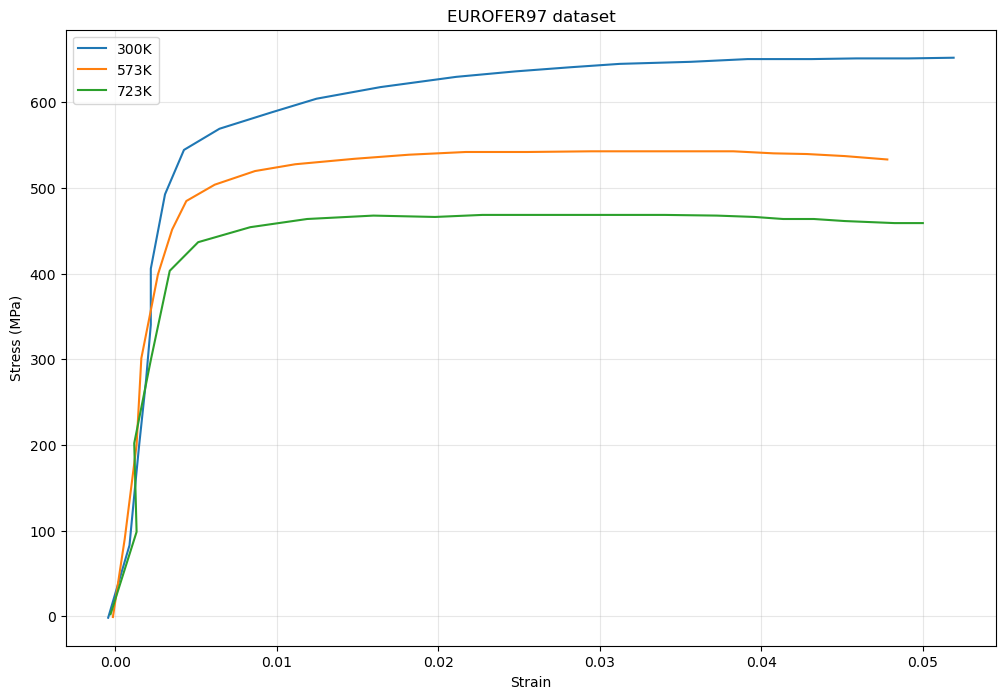

In [5]:
path = "EUROFER97_validation_data"
files = [f for f in sorted(os.listdir(path)) if f.startswith("Eurofer97") and f.endswith(".csv")]
pattern = re.compile(r"_(\d{3})k\.csv")

frames = []
for f in files:
    m = pattern.search(f)
    if m is None:
        raise ValueError(f"filename {f!r} does not match expected pattern")
    T = int(m.group(1))
    df = pd.read_csv(os.path.join(path, f))
    df["temperature"] = T
    frames.append(df)
EUROFER97_data = pd.concat(frames, ignore_index=True)
by_temp = EUROFER97_data.groupby("temperature")
exp_temps = sorted(EUROFER97_data["temperature"].unique())
fig, ax = plt.subplots(figsize=(12, 8))
max_strains = []

for T in exp_temps:
    df_T = by_temp.get_group(T)
    ax.plot(df_T["x"], df_T["y"], label=f"{T}K")
    max_strains.append(df_T["x"].iloc[-1])
ax.set_xlabel("Strain")
ax.set_ylabel("Stress (MPa)")
ax.set_title("EUROFER97 dataset")
ax.legend()
ax.grid(alpha=0.3)

In [6]:
batch_conditions = [(300, 9.259e-5), (573, 9.259e-5), (723, 9.259e-5)]

temperatures = torch.tensor([c[0] for c in batch_conditions], device=device)
rates = torch.tensor([c[1] for c in batch_conditions], device=device)

nbatch = len(batch_conditions)
ntime = 200
max_strain_list = torch.tensor([max_strains], dtype=torch.double, device=device).flatten()

time = torch.zeros((ntime, nbatch), device=device)
temperature = torch.zeros((ntime, nbatch), device=device)
loading = torch.zeros((ntime, nbatch, 6), device=device)

for i, (T, rate) in enumerate(batch_conditions):
    loading[:, i, 0] = torch.linspace(0.0, max_strain_list[i], ntime, device=device)
    time[:, i] = torch.linspace(0.0, max_strain_list[i] / rate, ntime, device=device)
    temperature[:, i] = T

print(
    f"\n--- Full Input Tensors ---\ntime: {time.shape}\ntemperature: {temperature.shape}\nloading: {loading.shape}"
)


--- Full Input Tensors ---
time: torch.Size([200, 3])
temperature: torch.Size([200, 3])
loading: torch.Size([200, 3, 6])


Interpolated data shape:
strain: torch.Size([200, 3, 6])
stress: torch.Size([200, 3, 6])


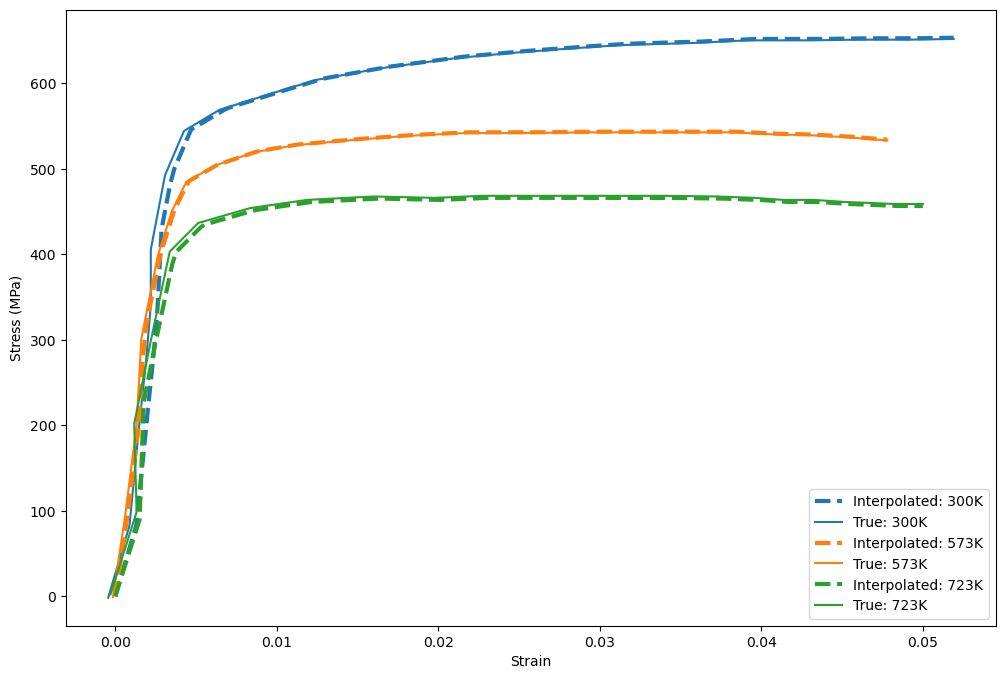

In [7]:
# Convert EXP data into torch tensors
exp_strain_data = torch.zeros_like(loading, device=device)
exp_stress_data = torch.zeros_like(loading, device=device)

for i, (T, rate) in enumerate(batch_conditions):
    target_strains = loading[:, i, 0].cpu().numpy()
    df_T = by_temp.get_group(T)
    src_strains = df_T["x"].to_numpy()
    src_stresses = df_T["y"].to_numpy()
    src_strains = src_strains[:] - src_strains[0]
    src_stresses = src_stresses[:] - src_stresses[0]
    interp_stress = np.interp(target_strains, src_strains, src_stresses)

    exp_strain_data[:, i, 0] = torch.tensor(target_strains, device=device)
    exp_stress_data[:, i, 0] = torch.tensor(interp_stress, device=device)

print(f"Interpolated data shape:")
print(f"strain: {exp_strain_data.shape}")
print(f"stress: {exp_stress_data.shape}")

plt.figure(figsize=(12, 8))
for i, (T, rate) in enumerate(batch_conditions):
    plt.plot(
        exp_strain_data[:, i, 0].cpu().numpy(),
        exp_stress_data[:, i, 0].cpu().numpy(),
        "--",
        color=f"C{i}",
        lw=3,
        label=f"Interpolated: {T}K",
    )
    df_T = by_temp.get_group(T)
    plt.plot(df_T["x"], df_T["y"], label=f"True: {T}K")
plt.xlabel("Strain")
plt.ylabel("Stress (MPa)")
plt.legend()

In [8]:
initial_params = {}
print("--- Before Reparametrization ---")
with torch.no_grad():
    for n, p in model.named_parameters():
        initial_params[n] = p.data.detach().clone()
        print(f"{n}: {p.data}, {p.shape}\n")

--- Before Reparametrization ---
discrete_equations.v_disl_B_k: 6.6e-11, torch.Size([])

discrete_equations.v_disl_T_0: 1530.42175, torch.Size([])

discrete_equations.v_disl_p: 0.65, torch.Size([])

discrete_equations.v_disl_q: 1.7, torch.Size([])

discrete_equations.v_disl_H_0: 2.17, torch.Size([])

discrete_equations.rho_m_rate_k1: 78000.0, torch.Size([])

discrete_equations.rho_m_rate_k2_0: 6750.0, torch.Size([])

discrete_equations.rho_m_rate_Q_d: 0.015, torch.Size([])



In [9]:
class LogRangeRescale(reparametrization.RangeRescale):
    """Map [0, 1] to [lb, ub] in log space, so an Adam step is a relative change."""

    def __init__(
        self,
        lb: torch.Tensor | float,
        ub: torch.Tensor | float,
        clamp: bool = True,
    ) -> None:
        super().__init__(lb, ub, clamp)
        self.lb = math.log(lb)
        self.ub = math.log(ub)
        self.clamp = clamp

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        if self.clamp:
            X = torch.clamp(X, 0, 1)

        return torch.exp(X * (self.ub - self.lb) + self.lb)

    def reverse(self, X: torch.Tensor) -> torch.Tensor:
        Y = (torch.log(X) - self.lb) / (self.ub - self.lb)

        if self.clamp:
            return torch.clamp(Y, 0, 1)

        return Y

In [10]:
Bk_scaler = LogRangeRescale(
    torch.tensor(1.0e-12, device=device), torch.tensor(1.0e-5, device=device)
)  # MPa*s
T_0_scaler = reparametrization.RangeRescale(
    torch.tensor(100.0, device=device), torch.tensor(5000.0, device=device)
)  # K
p_scaler = LogRangeRescale(torch.tensor(0.01, device=device), torch.tensor(10.0, device=device))
q_scaler = LogRangeRescale(torch.tensor(0.01, device=device), torch.tensor(10.0, device=device))
H0_scaler = reparametrization.RangeRescale(
    torch.tensor(0.1, device=device), torch.tensor(10.0, device=device)
)  # eV
k1_scaler = LogRangeRescale(
    torch.tensor(1000.0, device=device), torch.tensor(1.0e7, device=device)
)  # um^-1
k2_0_scaler = LogRangeRescale(
    torch.tensor(0.01, device=device), torch.tensor(100000.0, device=device)
)
Q_d_scaler = LogRangeRescale(
    torch.tensor(0.0001, device=device), torch.tensor(1.0, device=device)
)  # eV

model_reparameterizer = reparametrization.Reparameterizer(
    {
        "discrete_equations.v_disl_B_k": Bk_scaler,
        "discrete_equations.v_disl_T_0": T_0_scaler,
        "discrete_equations.v_disl_p": p_scaler,
        "discrete_equations.v_disl_q": q_scaler,
        "discrete_equations.v_disl_H_0": H0_scaler,
        "discrete_equations.rho_m_rate_k1": k1_scaler,
        "discrete_equations.rho_m_rate_k2_0": k2_0_scaler,
        "discrete_equations.rho_m_rate_Q_d": Q_d_scaler,
    },
    error_not_provided=True,
)
model_reparameterizer(model)
print(f"--- After Reparameterization ---")
initial_params_reparam = {}
for n, p in model.named_parameters():
    initial_params_reparam[n] = p.data.detach().clone()
    print(f"{n}: {p.data}, requires_grad={p.requires_grad}")

--- After Reparameterization ---
discrete_equations.parametrizations.v_disl_B_k.original: 0.25993484793455257, requires_grad=True
discrete_equations.parametrizations.v_disl_T_0.original: 0.291922806122449, requires_grad=True
discrete_equations.parametrizations.v_disl_p.original: 0.6043044522142852, requires_grad=True
discrete_equations.parametrizations.v_disl_q.original: 0.743482973792758, requires_grad=True
discrete_equations.parametrizations.v_disl_H_0.original: 0.20909090909090908, requires_grad=True
discrete_equations.parametrizations.rho_m_rate_k1.original: 0.47302365067262014, requires_grad=True
discrete_equations.parametrizations.rho_m_rate_k2_0.original: 0.8327576818330035, requires_grad=True
discrete_equations.parametrizations.rho_m_rate_Q_d.original: 0.5440228147639202, requires_grad=True


In [11]:
prior_cov = 0.05
prior_noise_scale = 10.0

mapper = stochastic.MapNormal(prior_cov)
hsmodel = stochastic.HierarchicalStatisticalModel(
    model, mapper, torch.tensor(prior_noise_scale, device=device)
)

In [12]:
nreps = 50
predict = Predictive(hsmodel, num_samples=nreps)
with torch.no_grad():
    untrained = predict(loading, time, temperature)["obs"]

/tmp/ipykernel_272362/4103467228.py:50: UserWarning: pyzag lowered torch._functorch.config.donated_buffer's default to False process-wide. AOTAutograd 'donated buffers' (torch>=2.12) are incompatible with pyzag's retain_graph=True adjoint over torch.compile'd models, which otherwise raises 'compiled with non-empty donated buffers'. To keep donated buffers enabled, restore torch._functorch.config._config['donated_buffer'].default = True -- compiled models differentiated through the adjoint will then error.
  solver = nonlinear.RecursiveNonlinearEquationSolver(
/home/quantumsurfer/.local/lib/python3.14/site-packages/pyzag/chunktime.py:135: UserWarning: Implicit solve did not succeed.  Results may be inaccurate...
  warnings.warn(


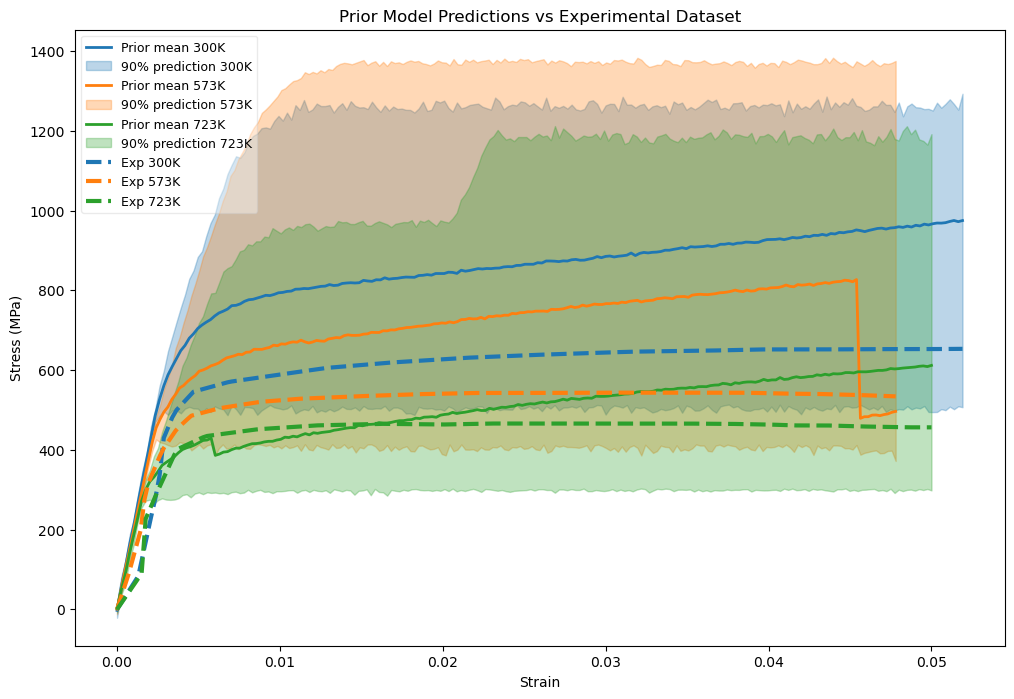

In [13]:
plt.figure(figsize=(12, 8))
plotted_labels = set()
for i, T in enumerate(temperatures):
    t_label = str(int(T.item()))
    temp_preds = untrained[:, :, i, 0]
    plt.plot(
        loading[:, i, 0].cpu(),
        temp_preds.mean(dim=0).cpu(),
        ls="-",
        color=f"C{i}",
        lw=2,
        label=f"Prior mean {t_label}K",
    )

    lo, hi = torch.quantile(temp_preds, torch.tensor([0.05, 0.95], device=device), dim=0)
    plt.fill_between(
        loading[:, i, 0].cpu(),
        lo.cpu(),
        hi.cpu(),
        color=f"C{i}",
        alpha=0.3,
        label=f"90% prediction {t_label}K",
    )

for i, T in enumerate(temperatures):
    t_label = str(int(T.item()))
    plt.plot(
        exp_strain_data[:, i, 0].cpu().numpy(),
        exp_stress_data[:, i, 0].cpu().numpy(),
        "--",
        lw=3,
        color=f"C{i}",
        label=f"Exp {t_label}K",
    )


plt.xlabel("Strain")
plt.ylabel("Stress (MPa)")
plt.title("Prior Model Predictions vs Experimental Dataset")
plt.legend(loc="best", framealpha=0.4, fontsize=9)
plt.show()

Loss: 3.73e+03: : 100%|██████████|300/300


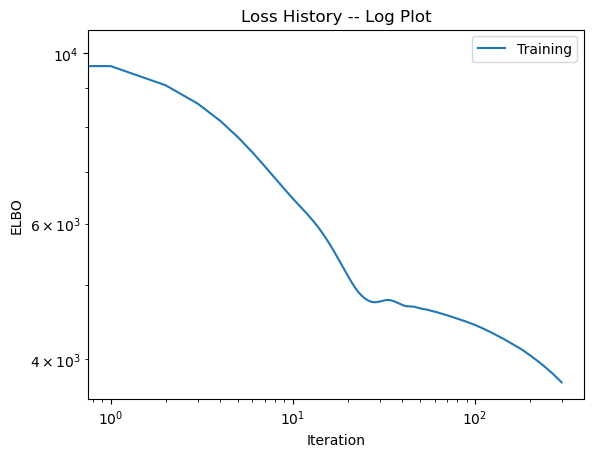

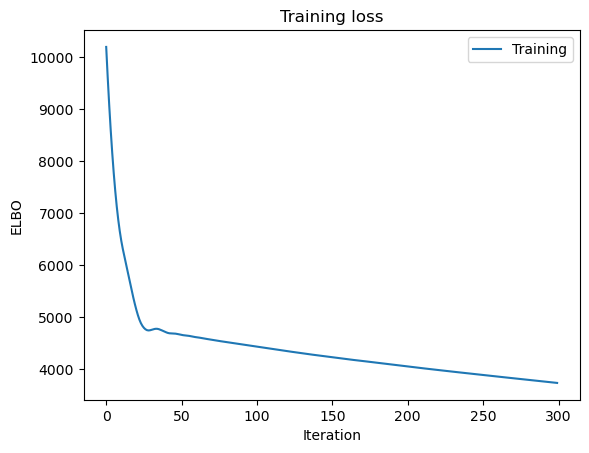

In [ ]:
guide = AutoDelta(hsmodel)
lr = 5e-4
niter = 300
num_samples = 1

optimizer = ClippedAdam({"lr": lr})
loss = Trace_ELBO(num_particles=num_samples)
svi = SVI(hsmodel, guide, optimizer, loss=loss)

titer = tqdm.tqdm(
    range(niter),
    bar_format="{desc}: {percentage:3.0f}%|{bar}|{n_fmt}/{total_fmt}{postfix}",
)
titer.set_description("Loss:")
loss_history = []
for i in titer:
    closs = svi.step(loading, time, temperature, results=exp_stress_data[..., 0:1])
    loss_history.append(closs)
    titer.set_description("Loss: %3.2e" % closs)

plt.figure()
plt.loglog(loss_history, label="Training")
plt.xlabel("Iteration")
plt.ylabel("ELBO")
plt.legend(loc="best")
plt.title("Loss History -- Log Plot")

plt.figure()
plt.plot(loss_history, label="Training")
plt.xlabel("Iteration")
plt.ylabel("ELBO")
plt.legend(loc="best")
plt.title("Training loss")
plt.show()

In [15]:
nreps = 50
predict = Predictive(hsmodel, guide=guide, num_samples=nreps)
with torch.no_grad():
    trained = predict(loading, time, temperature)["obs"]

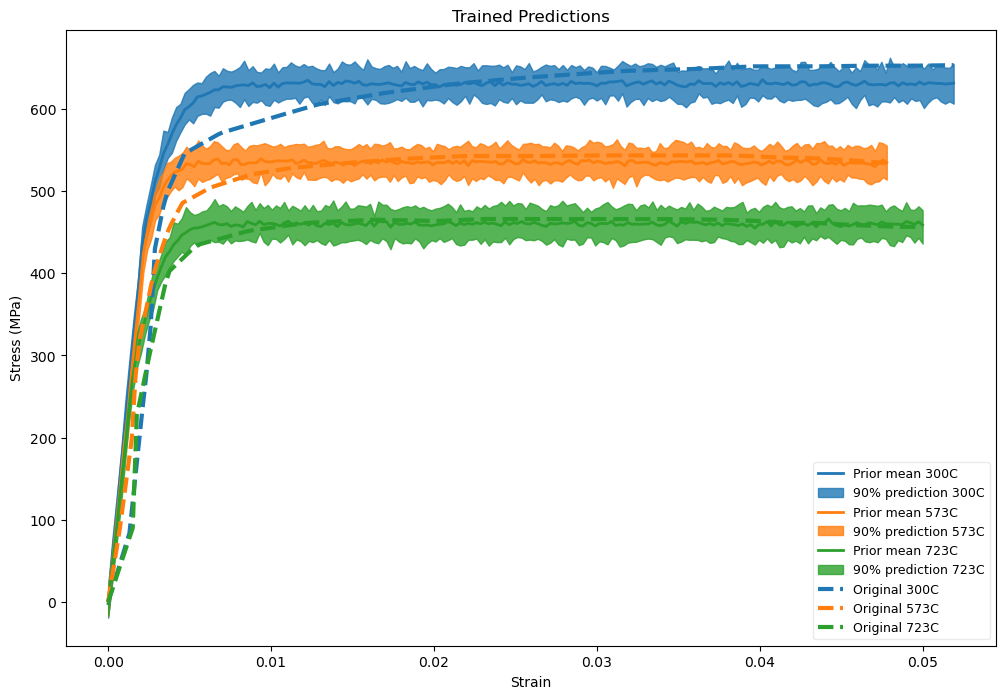

In [ ]:
plt.figure(figsize=(12, 8))
plotted_labels = set()
for i, T in enumerate(temperatures):
    t_label = str(int(T.item()))
    temp_preds = trained[:, :, i, 0]
    plt.plot(
        loading[:, i, 0].cpu(),
        temp_preds.mean(dim=0).cpu(),
        ls="-",
        color=f"C{i}",
        lw=2,
        label=f"Posterior mean {t_label}K",
    )

    lo, hi = torch.quantile(temp_preds, torch.tensor([0.05, 0.95], device=device), dim=0)
    plt.fill_between(
        loading[:, i, 0].cpu(),
        lo.cpu(),
        hi.cpu(),
        color=f"C{i}",
        alpha=0.8,
        label=f"90% prediction {t_label}K",
    )

for i, T in enumerate(temperatures):
    t_label = str(int(T.item()))
    plt.plot(
        exp_strain_data[:, i, 0].cpu().numpy(),
        exp_stress_data[:, i, 0].cpu().numpy(),
        "--",
        lw=3,
        color=f"C{i}",
        label=f"Original {t_label}K",
    )


plt.xlabel("Strain")
plt.ylabel("Stress (MPa)")
plt.title("Trained Predictions")
plt.legend(loc="best", framealpha=0.4, fontsize=9)
plt.show()

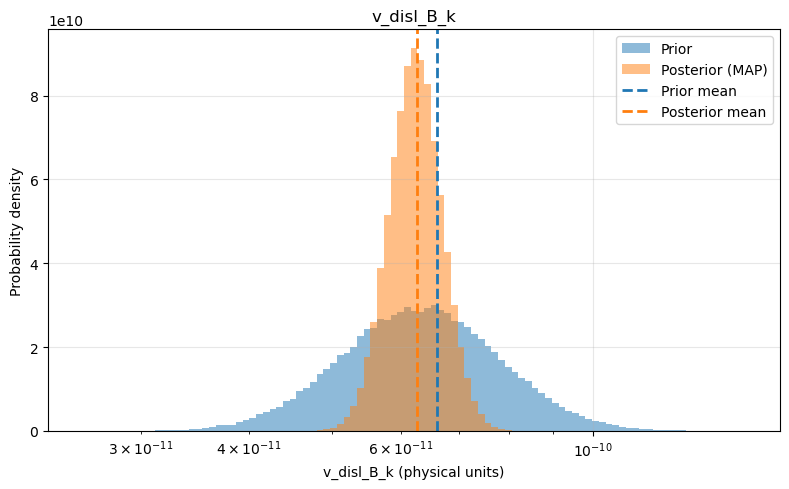

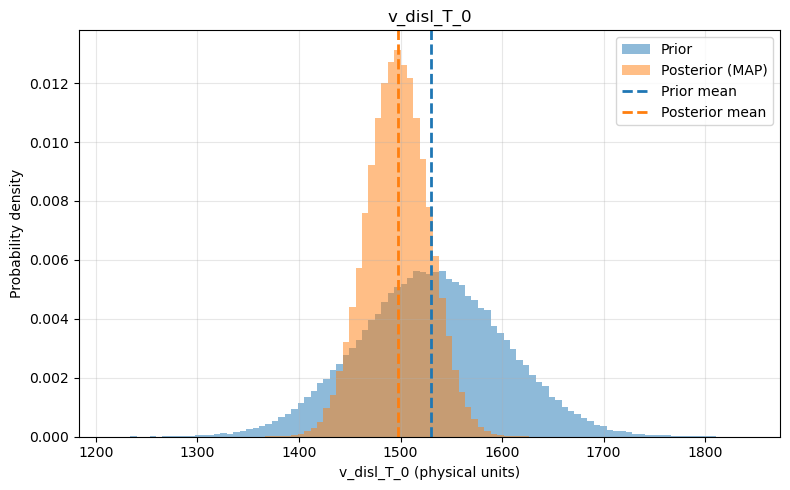

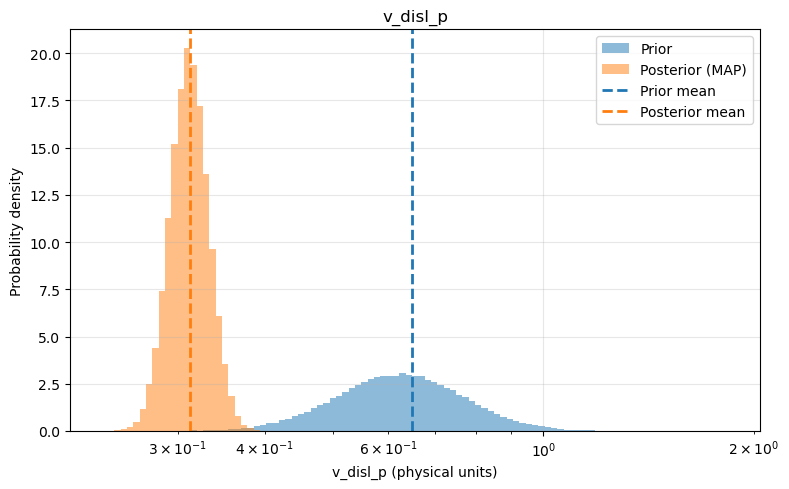

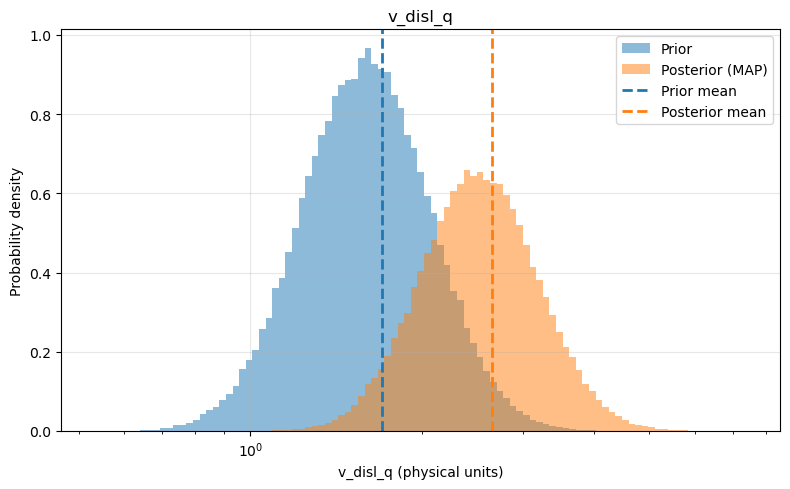

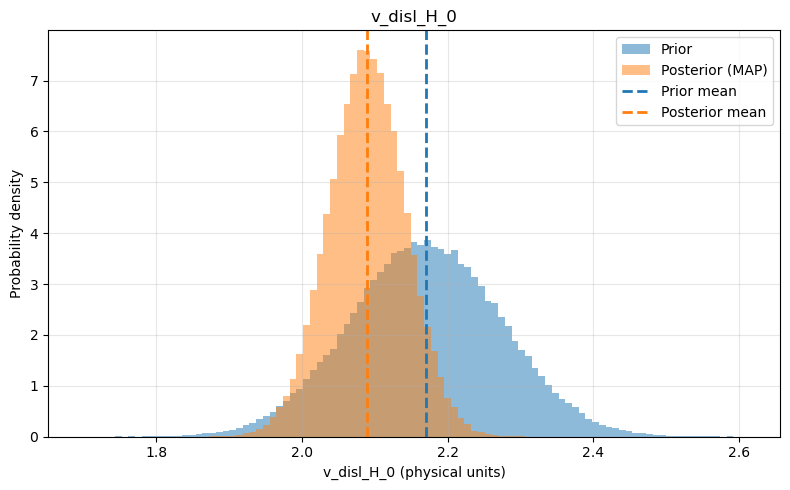

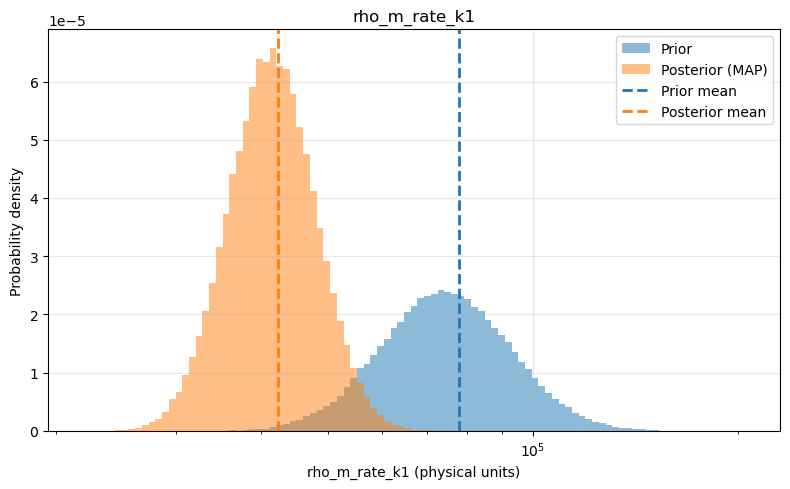

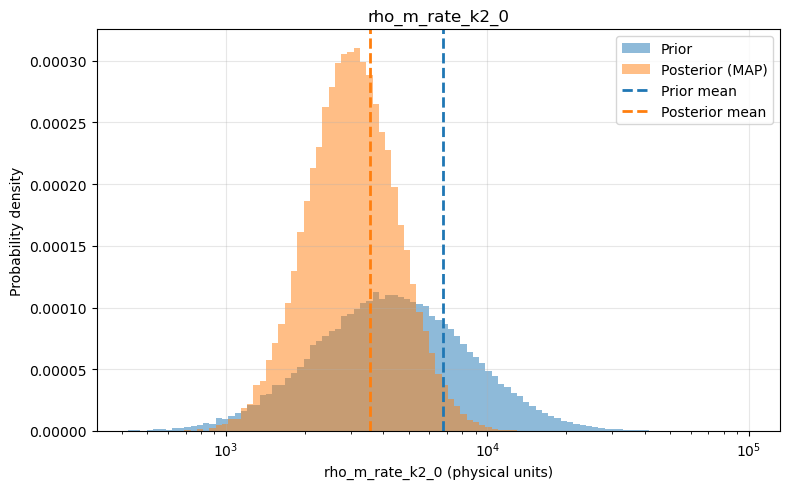

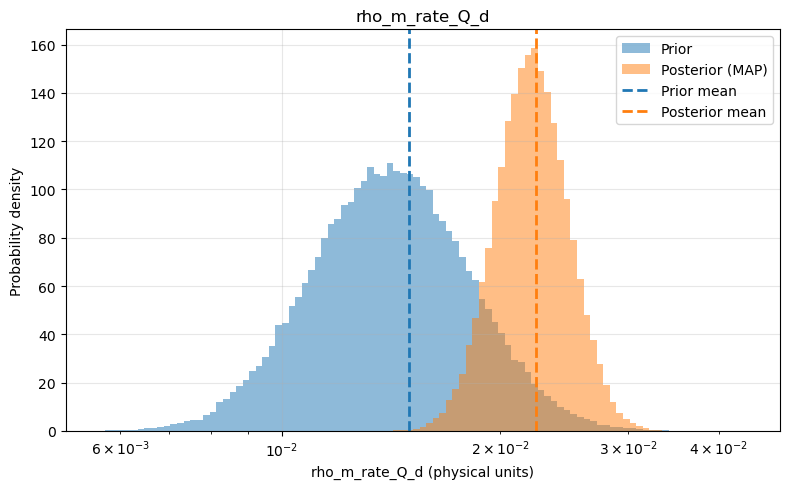

In [ ]:
nsamp = 100000
for _, _, n in hsmodel.bot:
    simple_name = ".".join([n.split(".")[i] for i in [0, 2]])  # e.g. discrete_equations.v_disl_B_k
    scaler = model_reparameterizer.map_dict[simple_name]
    param_name = simple_name.split(".")[-1]
    is_log = isinstance(scaler, LogRangeRescale)

    # [0,1]-space distributions (pyzag's MapNormal defines them here)
    prior_loc = initial_params_reparam[n]
    prior_scale = prior_cov * prior_loc.abs()
    post_loc = pyro.param(f"AutoDelta.{n}_loc").detach()
    post_scale = pyro.param(f"AutoDelta.{n}_scale").detach()

    # map samples to physical units (correct for both linear and log scalers)
    prior_phys = scaler.forward(dist.Normal(prior_loc, prior_scale).sample((nsamp,))).cpu().numpy()
    post_phys = scaler.forward(dist.Normal(post_loc, post_scale).sample((nsamp,))).cpu().numpy()

    both = np.concatenate([prior_phys, post_phys])
    bins = (
        np.logspace(np.log10(both.min()), np.log10(both.max()), 100)
        if is_log
        else np.linspace(both.min(), both.max(), 100),
    )

    plt.figure(figsize=(8, 5))
    plt.hist(prior_phys, bins=bins, density=True, alpha=0.5, color="C0", label="Prior")
    plt.hist(post_phys, bins=bins, density=True, alpha=0.5, color="C1", label="Posterior (MAP)")
    plt.axvline(scaler.forward(prior_loc).item(), color="C0", ls="--", lw=2, label="Prior mean")
    plt.axvline(scaler.forward(post_loc).item(), color="C1", ls="--", lw=2, label="Posterior mean")
    if is_log:
        plt.xscale("log")
    plt.xlabel(f"{param_name} (physical units)")
    plt.ylabel("Probability density")
    plt.title(param_name)
    plt.legend(loc="best")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()